# Day 4: Fund Performance Analytics

In [1]:
import os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(BASE_DIR, 'data', 'db')):
    BASE_DIR = os.getcwd()
os.chdir(BASE_DIR)

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect('data/db/bluestock_mf.db')
nav = pd.read_sql('SELECT * FROM fact_nav', conn)
nav['date'] = pd.to_datetime(nav['date'])
fund = pd.read_sql('SELECT * FROM dim_fund', conn)

## Scorecard Preview

In [2]:
scorecard = pd.read_csv('data/processed/fund_scorecard.csv')
scorecard.nlargest(10, 'score')

,amfi_code,expense_ratio_pct,cagr_1yr,cagr_3yr,cagr_5yr,sharpe,std_dev_ann,alpha,beta,max_drawdown,rank_3yr,rank_sharpe,rank_alpha,rank_expense,rank_max_dd,score
34,148567,1.46,0.195940,0.326075,NaN,1.448291,0.141937,0.269838,0.023684,-0.112657,39.0,40.0,34.0,18.0,33.0,100.000000
25,120505,1.36,0.284509,0.304852,NaN,1.180101,0.192909,0.292636,0.000549,-0.181885,36.0,36.0,38.0,26.0,16.0,95.362319
30,120843,1.45,0.256292,0.283890,NaN,1.306744,0.158870,0.273305,-0.022830,-0.129740,34.0,39.0,36.0,19.0,28.0,95.072464
2,100033,1.38,0.509938,0.311201,NaN,1.093699,0.189367,0.271954,0.005104,-0.162172,37.0,34.0,35.0,24.0,21.0,93.623188
24,120504,0.80,0.125866,0.311630,NaN,1.026524,0.143638,0.211948,0.016232,-0.125883,38.0,31.0,28.0,29.0,29.0,92.753623
16,119094,1.38,0.214166,0.336675,NaN,0.998231,0.194071,0.260767,-0.066265,-0.209609,40.0,30.0,32.0,24.0,13.0,89.275362
19,119551,1.54,0.578432,0.292237,NaN,1.208267,0.137414,0.232010,-0.031751,-0.150124,35.0,37.0,31.0,10.5,24.0,86.739130
36,148569,1.60,0.381481,0.280031,NaN,1.234930,0.176740,0.282704,0.018134,-0.163967,33.0,38.0,37.0,4.5,20.0,85.434783
3,101206,1.60,0.459404,0.278013,NaN,1.027213,0.145682,0.213998,0.021086,-0.112916,32.0,32.0,29.0,4.5,32.0,79.057971
21,119598,1.43,0.790143,0.256049,NaN,0.945308,0.251406,0.303370,-0.023196,-0.287060,29.0,27.0,40.0,20.0,5.0,78.115942


## Benchmark Chart

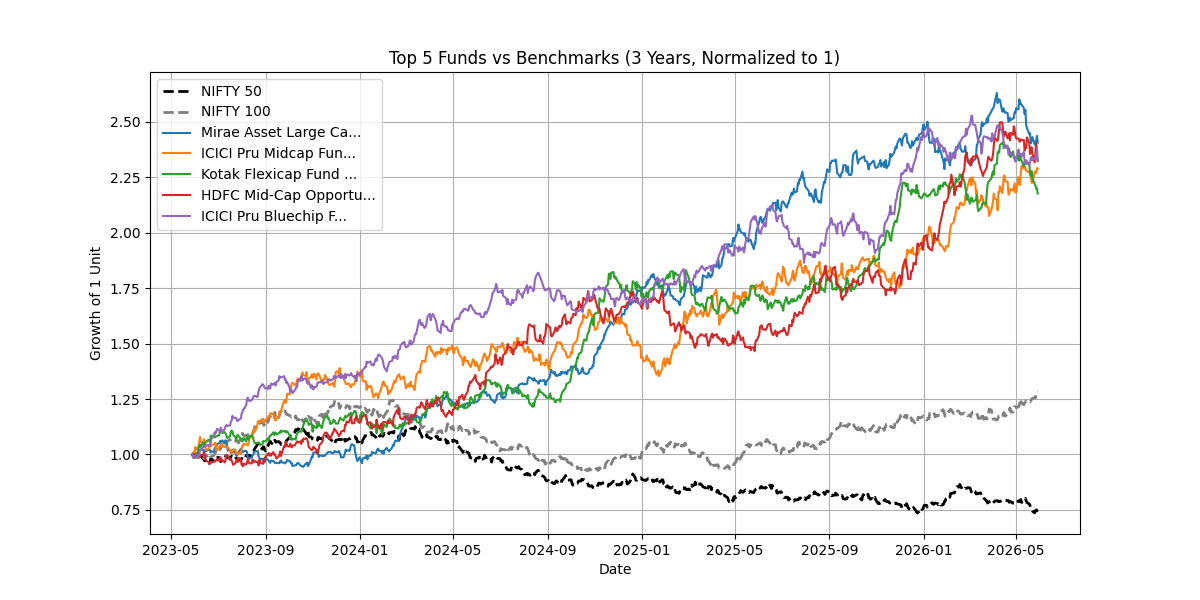

In [3]:
from IPython.display import Image
Image(filename='reports/benchmark_chart.png')